# <span style="color:red"> **LSN - Esercitazione 04**
### <span style="color:green"> 27.03.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

Note:

#### Esercizio 04.1
- devo forse usare ceil() al posto che int() in measure nel calcolo di pofv per individuare il corretto bin? cioè arrotondare per eccesso: ad esempio, se mi capita che v = 2.12, incremento _index_pofv di 3, di modo che sia nel corretto bin che contiene velocità 2-3?
#### Esercizio 04.2
- Penso che il grafico che ho prodotto sia abbastanza illeggibile. Meglio plottare su grafici diversi? Perché nella consegna parla di grafici al plurale? Cos'altro posso plottare?
- capire come rispondere alla seconda domanda. nell'es 3
- come dati iniziali lascio quelli nel codice originario o modifico come da consegna? modifico.
- **il fit è strano**
#### Esercizio 04.3
- nel codice, leggo input direttamente da cartella di output dell'esercizio 04.2. Meglio incollare direttamente nell'input i dati dell'output dell'es 4.2., ed eventualmente modificarli a ogni nuova simulazione. Ripristinare codice originario!!!!!

### <span style="color:blue">**Esercizio 04.1**

Ho incluso nel codice il calcolo della distribuzione $p(v*,T*)$. Il codice è già scritto in modo da fare data blocking.

## <span style="color:blue">**Esercizio 04.2**

Effettuo una stimulazione MD con un modello di Lennard-Jones per l'Argon, con parametri $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu, nelle seguenti condizioni:
- gas phase: $\rho^\star = 0.05$, $T^\star \sim  2.0$ (cut-off radius: $r_c = 5.0$)

partendo da una configurazione iniziale a entropia molto bassa:
1. posizione iniziale delle particelle: cristallo fcc che occupa metà del box di simulazione in ogni dimensione
2. distribuzione di velocità iniziale: $p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$, dove $v_{T^*}$ è adeguatamente connessa $T^*$. For example, this condition could be obtained by imposing that every particle has an initial velocity $\pm v_{T^*}$ for **only one** of its velocity components: $v_x$, $v_y$, $v_z$.

Mostro che, evolvendo una tale condizione iniale attraverso una simulazione di Dinamica Molecolare, la distribuzione di velocità tende ad approssimare la distribuzione di Maxwell-Boltzmann.

- **Produce some pictures that show this convergence**
- The evolution of the system moves towards the increasing of entropy (more homeogeneous configuration of particles)? What would you find by changing the direction of time? Comment on these aspects in your jupyter-notebook

**Note that** the MD simulation will conserve the total energy; thus the kinetic energy and the temperature are not constant of motion ... the comparison should be done with $p(v^*,T^*_{\rm eff})$ where $T^*_{\rm eff}$ is the effective temperature obtained once the system has been equilibrated.

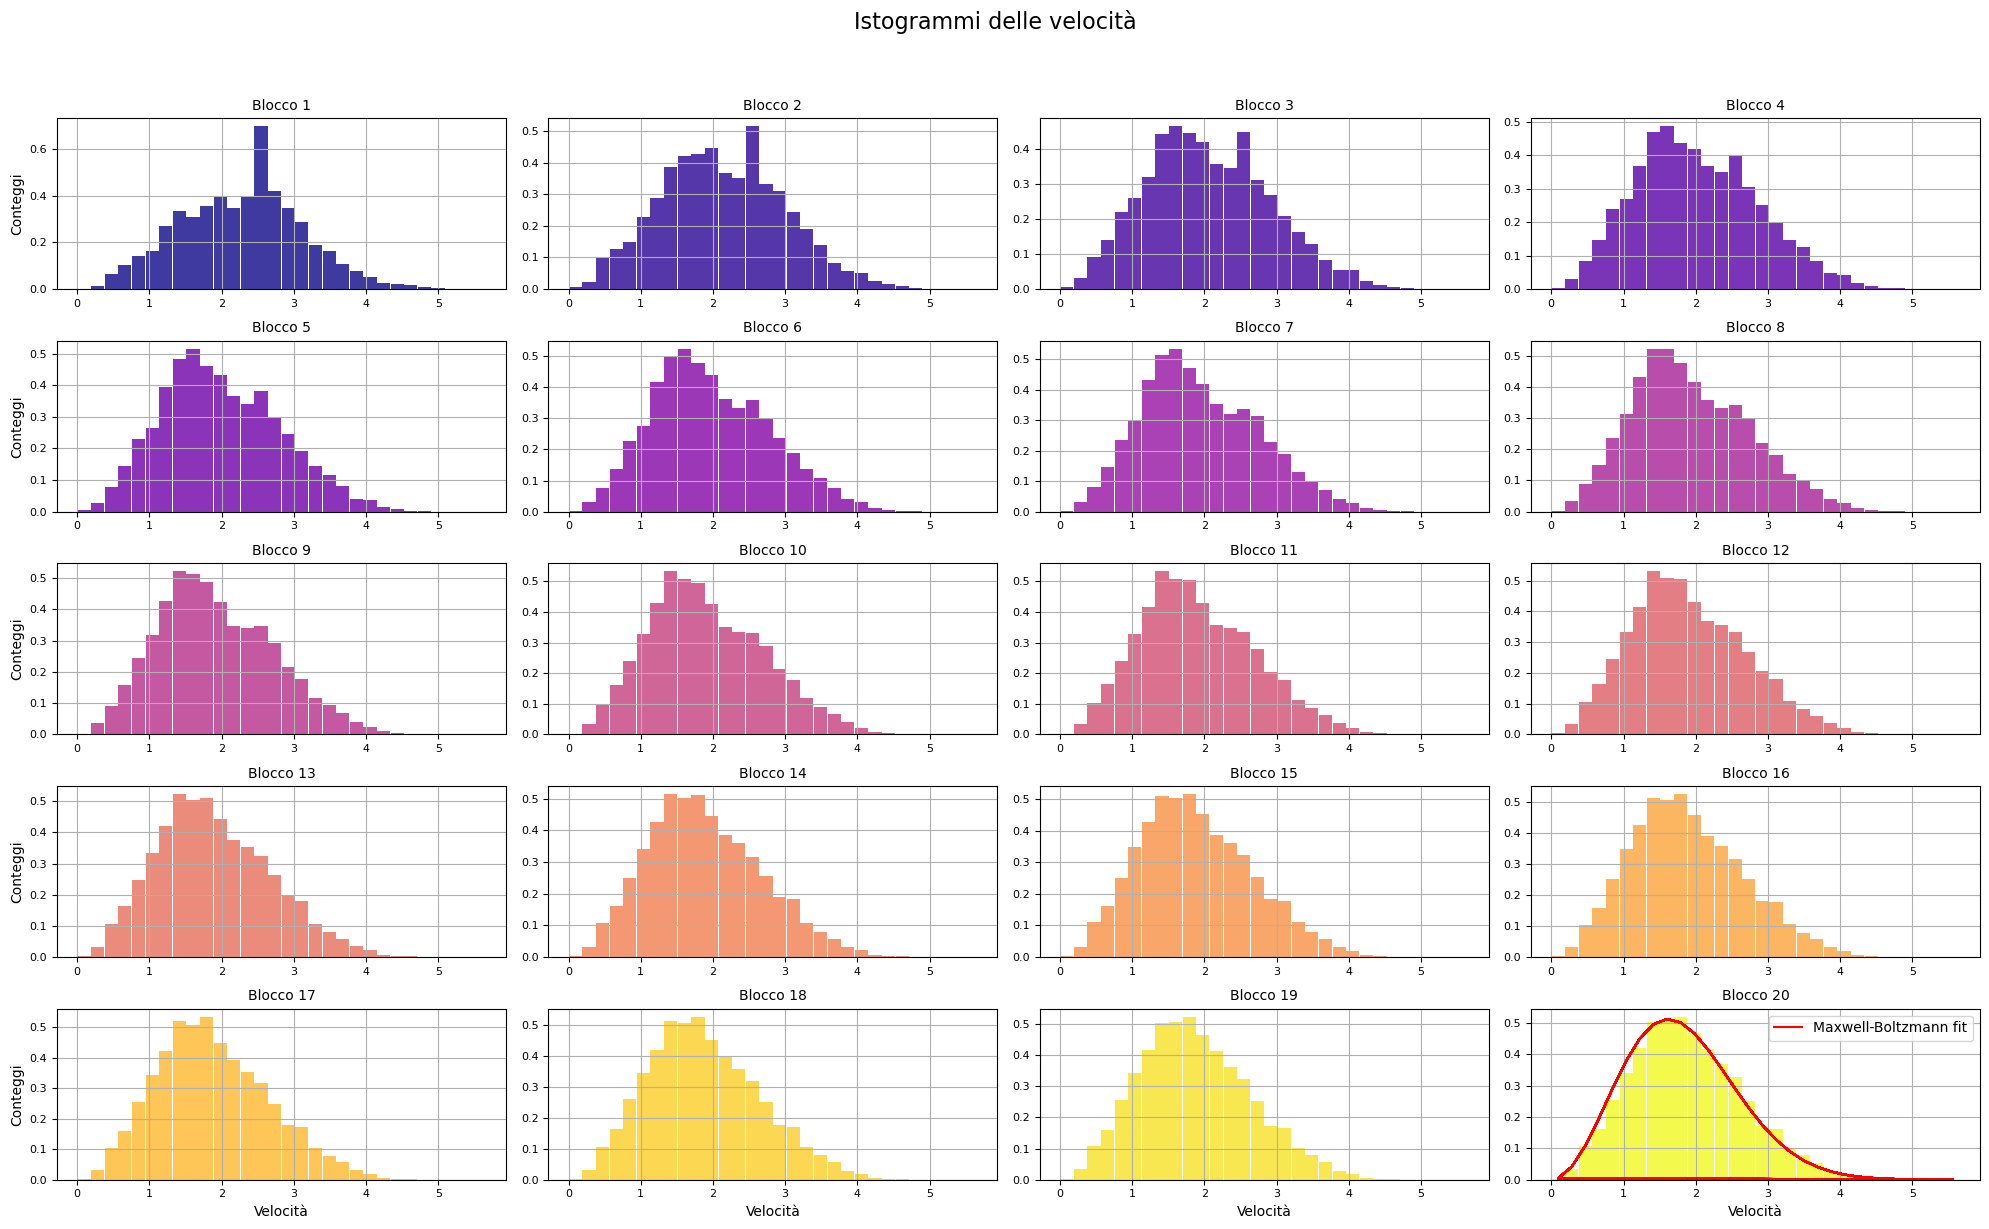

In [12]:
import matplotlib.pyplot as plt
import numpy as np


# Carico i dati dal file
data = np.loadtxt("simulazioni-eseguite/04.2/OUTPUT/pofv.dat")

# Estraggo le colonne
x = data[:, 0]   # Velocità
y = data[:, 1]   # Conteggi già calcolati
err = data[:, 2] # Errori

def maxwell_boltzmann(x):
    return 1/(2*np.pi*1.31)**(3.0/2.0) * 4 * np.pi * x**2 * np.exp(-x**2 / (2 * 1.31))

# Parametri
colors = plt.cm.plasma(np.linspace(0, 1, 20))  # 20 colori distinti
block_size = 30
n_blocks = 20

# Crea figura con 20 subplot (5 righe x 4 colonne)
fig, axes = plt.subplots(5, 4, figsize=(20, 12))
axes = axes.flatten()  # Facilita l'indicizzazione

for i in range(n_blocks):
    start_idx = i * block_size
    end_idx = (i + 1) * block_size
    
    # Istogramma manuale usando plt.bar()
    axes[i].bar(x[start_idx:end_idx], y[start_idx:end_idx], color=colors[i], alpha=0.8, width=(x[end_idx-1] - x[start_idx]) / block_size)
    
    axes[i].set_title(f'Blocco {i+1}', fontsize=10)
    axes[i].grid(True)
    axes[i].tick_params(labelsize=8)

    # Etichette solo sui margini
    if i % 4 == 0:
        axes[i].set_ylabel('Conteggi')
    if i >= 16:
        axes[i].set_xlabel('Velocità')

    if i == 19:
        axes[i].plot(x,maxwell_boltzmann(x),color='r', label="Maxwell-Boltzmann fit")

# Layout e titolo generale
plt.tight_layout()
plt.legend()
plt.suptitle('Istogrammi delle velocità', fontsize=16, y=1.02)
plt.subplots_adjust(top=0.93)

plt.show()



Ora inverto asse di percorrenza dei tempi per vedere se torno al cristallo con distribuzione omogenea di velocità iniziali e particelle che occupano metà del box di simulazione. 

## <span style="color:blue">**Esercizio 04.3**

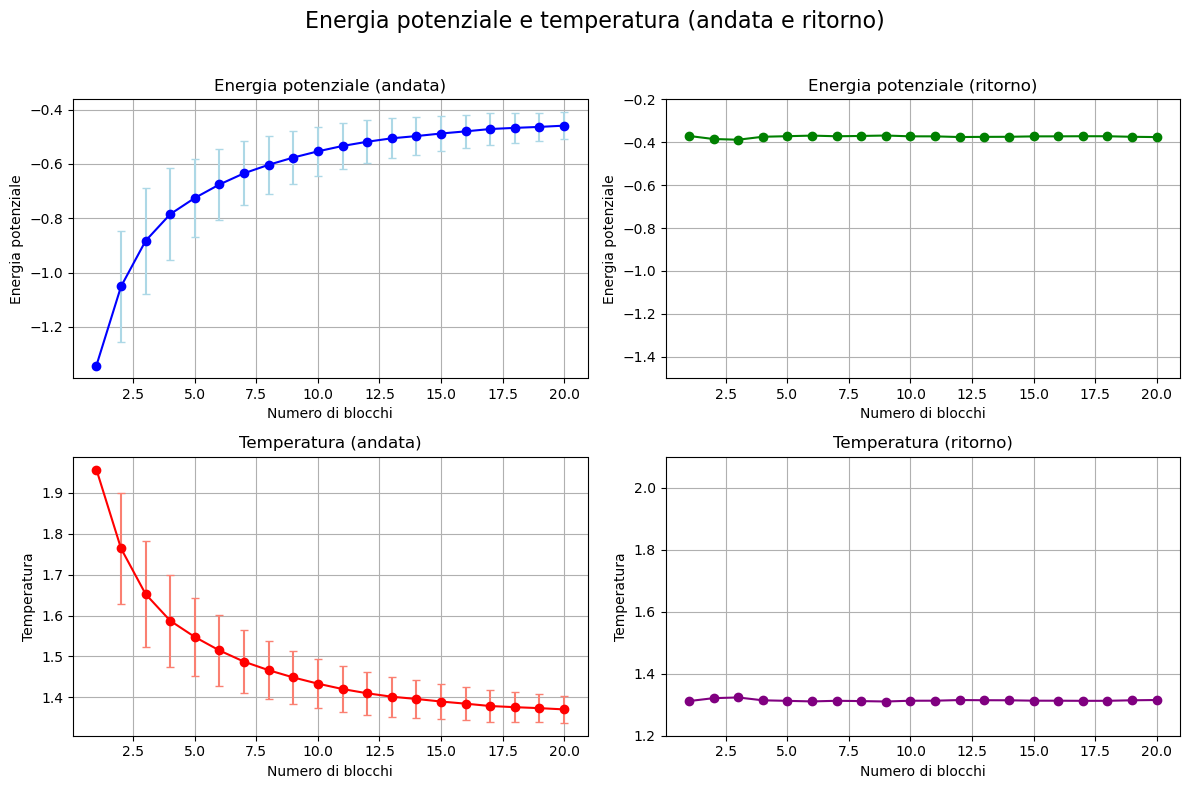

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Carico i dati dai file
data_pot_andata = np.loadtxt("simulazioni-eseguite/04.2/OUTPUT/potential_energy.dat")
data_pot_ritorno = np.loadtxt("simulazioni-eseguite/04.3/OUTPUT/potential_energy.dat")
data_temp_andata = np.loadtxt("simulazioni-eseguite/04.2/OUTPUT/temperature.dat")
data_temp_ritorno = np.loadtxt("simulazioni-eseguite/04.3/OUTPUT/temperature.dat")

# Estraggo i dati
x_pot_andata, y_pot_andata, err_pot_andata = data_pot_andata[:, 0], data_pot_andata[:, 2], data_pot_andata[:, 3]
x_pot_ritorno, y_pot_ritorno, err_pot_ritorno = data_pot_ritorno[:, 0], data_pot_ritorno[:, 2], data_pot_ritorno[:, 3]
x_temp_andata, y_temp_andata, err_temp_andata = data_temp_andata[:, 0], data_temp_andata[:, 2], data_temp_andata[:, 3]
x_temp_ritorno, y_temp_ritorno, err_temp_ritorno = data_temp_ritorno[:, 0], data_temp_ritorno[:, 2], data_temp_ritorno[:, 3]

# Creo una figura con 2 righe e 2 colonne
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Energia potenziale e temperatura (andata e ritorno)", fontsize=16)

# Plot 1: Energia potenziale (andata)
axs[0, 0].errorbar(x_pot_andata, y_pot_andata, yerr=err_pot_andata, fmt='o-', color='blue', ecolor='lightblue', capsize=3)
axs[0, 0].set_title("Energia potenziale (andata)")
axs[0, 0].set_xlabel("Numero di blocchi")
axs[0, 0].set_ylabel("Energia potenziale")
axs[0, 0].grid(True)

# Plot 2: Energia potenziale (ritorno)
axs[0, 1].errorbar(x_pot_ritorno, y_pot_ritorno, yerr=err_pot_ritorno, fmt='o-', color='green', ecolor='lightgreen', capsize=3)
axs[0, 1].set_title("Energia potenziale (ritorno)")
axs[0, 1].set_xlabel("Numero di blocchi")
axs[0, 1].set_ylabel("Energia potenziale")
axs[0,1].set_ylim(-1.5,-0.2)
axs[0, 1].grid(True)

# Plot 3: Temperatura (andata)
axs[1, 0].errorbar(x_temp_andata, y_temp_andata, yerr=err_temp_andata, fmt='o-', color='red', ecolor='salmon', capsize=3)
axs[1, 0].set_title("Temperatura (andata)")
axs[1, 0].set_xlabel("Numero di blocchi")
axs[1, 0].set_ylabel("Temperatura")
axs[1, 0].grid(True)

# Plot 4: Temperatura (ritorno)
axs[1, 1].errorbar(x_temp_ritorno, y_temp_ritorno, yerr=err_temp_ritorno, fmt='o-', color='purple', ecolor='violet', capsize=3)
axs[1, 1].set_title("Temperatura (ritorno)")
axs[1, 1].set_xlabel("Numero di blocchi")
axs[1, 1].set_ylabel("Temperatura")
axs[1,1].set_ylim(1.2,2.1)
axs[1, 1].grid(True)

# Adatto la spaziatura
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
